Final Project: Business Analytics

Project A: Employee Performance and Retention Analysis

The objective of this project is to analyse HR data to assess employee performance, identify
trends influencing retention, and provide recommendations for improving employee
productivity and reducing turnover

1: Import Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns



2: Load Dataset

In [2]:
# Load Dataset
df = pd.read_csv('Employees_Data.csv')

df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61





3: Basic Data Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


In [4]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17417.000000,17417.000000,17417.000000,16054.000000,17417.000000,17417.000000,17417.000000,17417.000000
mean,39083.491129,1.250732,34.807774,3.345459,5.801860,0.358845,0.023368,63.176322
std,22707.024087,0.595692,7.694046,1.265386,4.175533,0.479675,0.151074,13.418179
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19281.000000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39122.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [5]:
# Ckeck missing or null values

print(df.isnull().sum())

employee_id                 0
department                  0
region                      0
education                 771
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating     1363
length_of_service           0
KPIs_met_more_than_80       0
awards_won                  0
avg_training_score          0
dtype: int64


4: Data Processing and Cleaning

In [6]:
# fill numerical missing values with median 

num_cols = df.select_dtypes(include=np.number).columns

In [7]:
# fill categorical missing values with mode 

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
# Handle missing values: 

df['education'] = df['education'].fillna(df['education'].mode()[0])
df['previous_year_rating'] = df['previous_year_rating'].fillna(0)

In [9]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,0.0,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [10]:
# checking null values

df.isnull().sum()

employee_id              0
department               0
region                   0
education                0
gender                   0
recruitment_channel      0
no_of_trainings          0
age                      0
previous_year_rating     0
length_of_service        0
KPIs_met_more_than_80    0
awards_won               0
avg_training_score       0
dtype: int64

In [11]:
# Checking duplicate records and values

df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17412    False
17413    False
17414     True
17415     True
17416    False
Length: 17417, dtype: bool

In [12]:
#Remove Duplicates

df.drop_duplicates(inplace=True)

In [13]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
17410    False
17411    False
17412    False
17413    False
17416    False
Length: 17415, dtype: bool

5: Performance Analysis 

In [14]:
# Average Training score by Department 

dept_score = df.groupby("department")["avg_training_score"].mean().reset_index()

dept_score

,department,avg_training_score
0,Analytics,84.565115
1,Finance,60.326683
2,HR,50.386282
3,Legal,59.533133
4,Operations,60.351589
5,Procurement,70.180357
6,R&D,84.451807
7,Sales & Marketing,50.056614
8,Technology,79.847658


<Figure size 600x400 with 0 Axes>

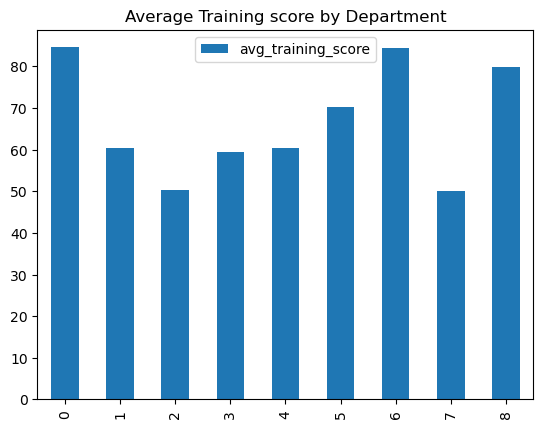

In [15]:
# visualisations of Average Training Sccore by department

plt.figure(figsize=(6,4))

dept_score.plot(kind="bar")
plt.title("Average Training score by Department")
plt.xticks(rotation=90)
plt.show()  

In [16]:
# KPI impact on Performance

kpi_rating = df.groupby("KPIs_met_more_than_80")["previous_year_rating"].mean().reset_index()

kpi_rating

,KPIs_met_more_than_80,previous_year_rating
0,0,2.78549
1,1,3.61696


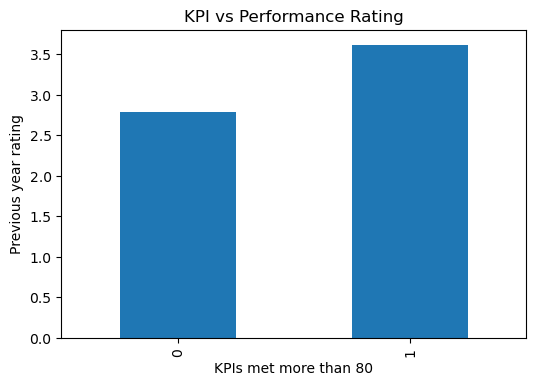

In [17]:
plt.figure(figsize=(6,4))
kpi_rating = df.groupby("KPIs_met_more_than_80")["previous_year_rating"].mean()

kpi_rating.plot(kind="bar")
plt.title("KPI vs Performance Rating")
plt.xlabel("KPIs met more than 80")
plt.ylabel("Previous year rating")
plt.show()

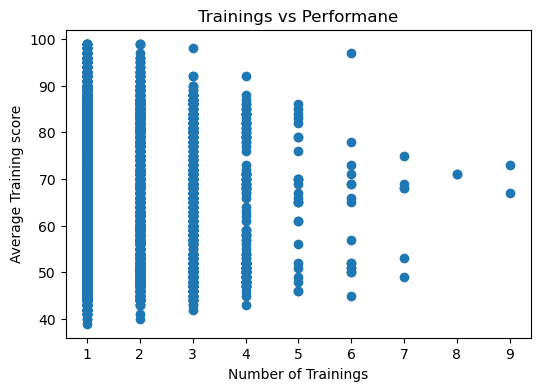

In [18]:
# Training vs Performance

plt.figure(figsize=(6,4)) 
plt.scatter(df["no_of_trainings"], df["avg_training_score"])
plt.xlabel("Number of Trainings")
plt.ylabel("Average Training score")
plt.title("Trainings vs Performane")
plt.show()      

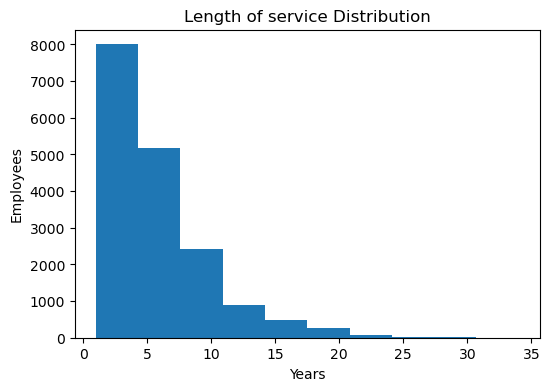

In [19]:
# Length of service Distribution

plt.figure(figsize=(6,4))
plt.hist(df["length_of_service"])
plt.title("Length of service Distribution")
plt.xlabel("Years")
plt.ylabel("Employees")
plt.show()

In [20]:
# Awards vs Rentation

awards_retention = df.groupby("awards_won")["length_of_service"].mean().reset_index()

awards_retention

,awards_won,length_of_service
0,0,5.826846
1,1,4.742015


6: Retention Trends Analysis

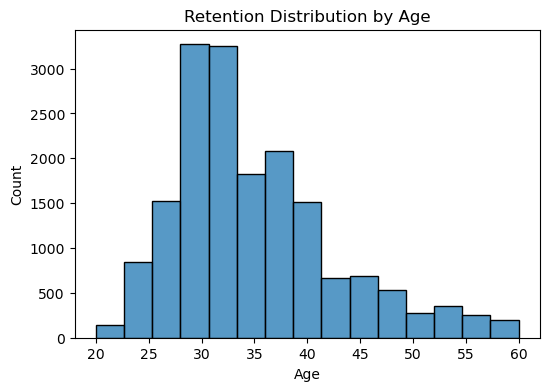

In [21]:
#  Retention by Age
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=15)
plt.title("Retention Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


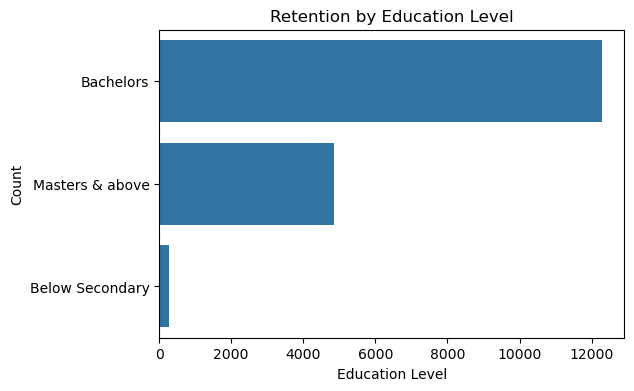

In [22]:
#  Retention by Education
plt.figure(figsize=(6,4))
sns.countplot(df["education"])
plt.title("Retention by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()


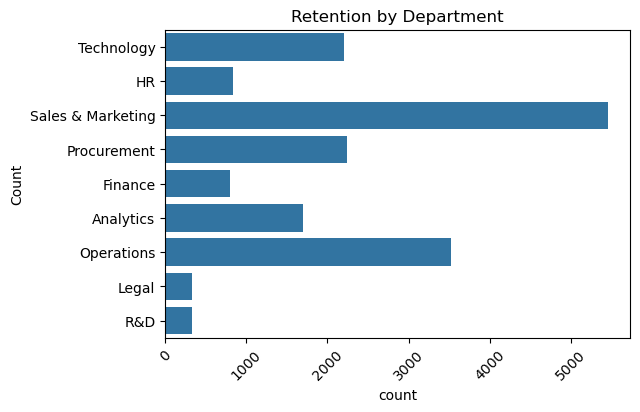

In [23]:
# Retention by Department
plt.figure(figsize=(6,4))
sns.countplot(df["department"])
plt.title("Retention by Department")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()


7: key Insights of Report 

* Employees who met more than 80% of KPIs have higher previous year performance ratings.
* Higher average training scores are positively associated with better performance.
* Employees who received awards tend to have longer length of service.
* certain departments show lower average training scores and ratings, indicating performance gaps.
* Most employees fall within the mid-age and mid-tenure range, suggesting a stable workforce structure.

8: Recommendations

* Increase targeted training programs for low-performing departments.
* Introduce performance-based incentives for employees meeting KPIs targets.
* Strengthen employee recognition programs (awards, bonuses) to improve retention.
* Provide mentorship programs for employees with shorter tenure (1-3years).
* Conduct regular performance reviews and feedback sessions to improve productivity.